In [27]:
import json
from pathlib import Path
from collections import defaultdict
from typing import Callable

RUNS_DIR = Path("/work/nvme/bbjs/sbharadwaj/powsm/xeuspr/exp/runs")

DATASETS = {
    "voxangeles": "decodedv3.voxangeles",
    "doreco":     "decodedv3.doreco",
    "tusom":      "decodedv3.tusom2021",
}

# Per-dataset function: passthrough dict -> language string
LANG_FN: dict[str, Callable[[dict], str]] = {
    "voxangeles": lambda p: p["utt_id"].split("-")[0],
    "doreco":     lambda p: p.get("lang_sym", "unk"),
    "tusom":      lambda p: p.get("lang_sym", "unk"),
}


def load_jsonl_shards(model_dir: Path) -> dict:
    records = {}
    for shard in sorted(model_dir.glob("transcription.*.jsonl")):
        with open(shard) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                records.update(obj)
    return records


def load_dataset_predictions(
    dataset: str,
    models: list[str],
    gt_field: str = "target",
    pred_field: str = "processed_transcript",
    key_field: str = "utt_id",
    lang_fn: Callable[[dict], str] | None = None,
) -> dict[str, dict[str, dict[str, dict[str, str]]]]:
    """
    Load decoded outputs for a dataset from decodedv3 JSONL files.

    Returns
    -------
    dict  {model_name -> {lang -> {utt_id -> {"prediction": str, "transcription": str}}}}
    """
    dataset_dir = RUNS_DIR / DATASETS[dataset]
    if lang_fn is None:
        lang_fn = LANG_FN[dataset]

    result = {}
    for model_name in models:
        model_dir = dataset_dir / model_name
        if not model_dir.exists():
            print(f"[warn] {model_dir} does not exist, skipping")
            continue
        records = load_jsonl_shards(model_dir)
        by_lang: dict[str, dict] = defaultdict(dict)
        for _, item in records.items():
            passthrough = item["passthrough"]
            utt_id = passthrough[key_field]
            lang = lang_fn(passthrough)
            prediction = item["pred"][0][pred_field]
            transcription = passthrough[gt_field]
            by_lang[lang][utt_id] = {"prediction": prediction, "transcription": transcription}

        result[model_name] = dict(by_lang)
        n_utts = sum(len(v) for v in by_lang.values())
        print(f"  {model_name}: {n_utts} utts across {len(by_lang)} lang(s)")
    return result


MODEL = 'xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000'
print("=== voxangeles ===")
voxangeles_preds = load_dataset_predictions("voxangeles", models=[MODEL])
print("\n=== doreco ===")
doreco_preds = load_dataset_predictions("doreco", models=[MODEL])
print("\n=== tusom ===")
tusom_preds = load_dataset_predictions("tusom", models=[MODEL])

=== voxangeles ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 5445 utts across 95 lang(s)

=== doreco ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 18734 utts across 45 lang(s)

=== tusom ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 2255 utts across 1 lang(s)


In [30]:
import sys
sys.path.insert(0, "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr")

import pandas as pd
from tqdm.auto import tqdm
from src.metrics.phone_recognition import PhoneRecognitionEvaluator


def compute_metrics(
    dataset_name: str,
    preds: dict[str, dict[str, dict]],
    compute_inventory: bool = False,
) -> pd.DataFrame:
    """
    Compute phone recognition metrics for all models and languages in preds.
    Parameters
    ----------
    dataset_name : str
        Name of the dataset (used as a column in the output DataFrame).
    preds : dict
        {model_name -> {lang_sym -> {utt_id -> {"prediction": str, "transcription": str}}}}
    Returns
    -------
    pd.DataFrame
        One row per (model, language) with columns: dataset, model, language,
        N, phones, PER, FER, FED, PFER, SUB, INS, DEL.
        Also includes a "macro" row per model averaging over languages (if >1 lang).
    """
    evaluator = PhoneRecognitionEvaluator(normalize_ipa=True)
    rows = []

    for model_name, lang_data in tqdm(preds.items(), desc=f"{dataset_name} models"):
        per_lang_summaries = []
        for lang, utt_data in tqdm(lang_data.items(), desc=model_name, leave=False):
            summary, _ = evaluator.evaluate(
                utt_data,
                compute_inventory=compute_inventory,
                tqdm_enabled=False,
            )
            per_lang_summaries.append(summary)
            rows.append({
                "dataset": dataset_name,
                "model": model_name,
                "language": lang,
                "N": summary.N,
                "phones": summary.phones,
                "PER": summary.PER,
                "FER": summary.FER,
                "FED": summary.FED,
                "PFER": summary.PFER,
                "SUB": summary.SUB,
                "INS": summary.INS,
                "DEL": summary.DEL,
            })

        # Macro-average across languages (weighted by nothing — one row per lang)
        if len(per_lang_summaries) > 1:
            rows.append({
                "dataset": dataset_name,
                "model": model_name,
                "language": "__macro__",
                "N": sum(s.N for s in per_lang_summaries),
                "phones": sum(s.phones for s in per_lang_summaries),
                "PER":  sum(s.PER  for s in per_lang_summaries) / len(per_lang_summaries),
                "FER":  sum(s.FER  for s in per_lang_summaries) / len(per_lang_summaries),
                "FED":  sum(s.FED  for s in per_lang_summaries),
                "PFER": sum(s.PFER for s in per_lang_summaries) / len(per_lang_summaries),
                "SUB":  sum(s.SUB  for s in per_lang_summaries) / len(per_lang_summaries),
                "INS":  sum(s.INS  for s in per_lang_summaries) / len(per_lang_summaries),
                "DEL":  sum(s.DEL  for s in per_lang_summaries) / len(per_lang_summaries),
            })

    return pd.DataFrame(rows)


df_voxangeles = compute_metrics("voxangeles", voxangeles_preds)
# df_doreco     = compute_metrics("doreco",     doreco_preds)
# df_tusom      = compute_metrics("tusom",      tusom_preds)

# df_all = pd.concat([df_voxangeles, df_doreco, df_tusom], ignore_index=True)
# print(df_all[df_all["language"].isin(["unk", "__macro__"])].to_string(index=False))

voxangeles models: 100%|██████████| 1/1 [00:01<00:00,  1.63s/it]


In [31]:
import numpy as np
from iso639 import Lang


def lang_name(code: str) -> str:
    try:
        return Lang(code).name
    except Exception:
        return code


evaluator = PhoneRecognitionEvaluator(normalize_ipa=True)

utt_rows = []
for model_name, lang_data in voxangeles_preds.items():
    for lang, utt_data in lang_data.items():
        _, instance_metrics = evaluator.evaluate(
            utt_data, compute_inventory=False, tqdm_enabled=False
        )
        name = lang_name(lang)
        for utt_id, metrics in instance_metrics.items():
            utt_rows.append({
                "utt_id":        utt_id,
                "langcode":      lang,
                "langname":      name,
                "reference":     utt_data[utt_id]["transcription"],
                "predicted":     utt_data[utt_id]["prediction"],
                "pfer":          metrics["pfer"],
                "fer":           metrics["fer"],
                "fed":           metrics["fed"],
                "per":           metrics["per"],
            })

df_utt = pd.DataFrame(utt_rows)
print(df_utt.shape)
df_utt.head()

(5445, 9)


,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per
0,lit-002-067-28,lit,Lithuanian,iːstʲɾʲɪʒʲaɪ,ɪstrʒɑjəjɪstrɪʒɑs,9.625000,110.156250,8.812500,175.000000
1,lit-002-069-29,lit,Lithuanian,iispuːdʲɪs,is̪pud͡ʑis̪,1.333333,15.625000,1.250000,75.000000
2,lit-002-070-30,lit,Lithuanian,dʲeːka,d̪ieka,1.125000,26.041667,1.041667,75.000000
3,lit-002-111-31,lit,Lithuanian,tʊɾʲtʲɛ,t̪urt̪e,0.291667,5.416667,0.270833,100.000000
4,lit-002-112-32,lit,Lithuanian,tʊɾtas,t̪ɔrt̪as̪,0.166667,2.777778,0.166667,83.333333


In [41]:
df_utt.groupby("langcode")["fer"].mean().sort_values(ascending=False)

langcode
wuu    41.417254
col    41.228923
led    38.858696
cbv    37.115050
ady    29.202086
         ...    
deg     5.720730
cha     5.351769
eus     5.242402
bem     4.894053
fub     4.076087
Name: fer, Length: 95, dtype: float64

In [26]:
import re
import yaml

IPAPACK_YAML = Path("/work/nvme/bbjs/sbharadwaj/powsm/xeuspr/configs/data/ipapack_index.yaml")
_TASK_TOKENS = {"pr", "asr", "g2p", "p2g", "notimestamps"}
_TRAIN_SPLITS = {"train"}

def _extract_langs_from_text_file(path: str) -> set[str]:
    """Read a Kaldi text file and return unique language tags (ISO 639-3)."""
    langs = set()
    with open(path) as f:
        for line in f:
            # first field after utt_id is the tag string e.g. "<eng><pr><notimestamps>"
            parts = line.split(maxsplit=1)
            if len(parts) < 2:
                continue
            tags = re.findall(r"<([a-z0-9]+)>", parts[1])
            for tag in tags:
                if tag not in _TASK_TOKENS:
                    langs.add(tag)
                    break  # first non-task tag is the language
    return langs

with open(IPAPACK_YAML) as f:
    ipapack = yaml.safe_load(f)

TRAIN_LANGS: set[str] = set()
for split_name, split_cfg in ipapack["datasets"].items():
    if split_name not in _TRAIN_SPLITS:
        continue
    lang_file = split_cfg.get("language")
    if lang_file is None:
        continue
    # wav_scp can be a dict of multiple scps; language file is always a single path
    print(f"  Reading {split_name}: {lang_file}")
    TRAIN_LANGS |= _extract_langs_from_text_file(lang_file)

TRAIN_LANGS = sorted(TRAIN_LANGS)
print(f"\nTotal training languages: {len(TRAIN_LANGS)}")
print(TRAIN_LANGS)

  Reading train: /work/hdd/bbjs/shared/powsm/s2t1/dump/raw/train_fixed/text

Total training languages: 79
['afr', 'amh', 'ara', 'aze', 'bak', 'bel', 'ben', 'bos', 'bul', 'cat', 'ceb', 'ces', 'cmn', 'cym', 'dan', 'deu', 'ell', 'eng', 'est', 'eus', 'fin', 'fra', 'ful', 'glg', 'hau', 'hin', 'hrv', 'hun', 'ind', 'isl', 'ita', 'jav', 'jpn', 'kat', 'kaz', 'kin', 'kir', 'kmr', 'lit', 'mal', 'mar', 'mkd', 'mlt', 'mon', 'mri', 'msa', 'nld', 'nob', 'ori', 'orm', 'pan', 'pol', 'por', 'ron', 'rus', 'sin', 'skr', 'slk', 'slv', 'sna', 'spa', 'srp', 'swa', 'swe', 'tam', 'tat', 'tel', 'tgk', 'tha', 'tur', 'uig', 'ukr', 'urd', 'uzb', 'vie', 'xho', 'yor', 'yue', 'zul']


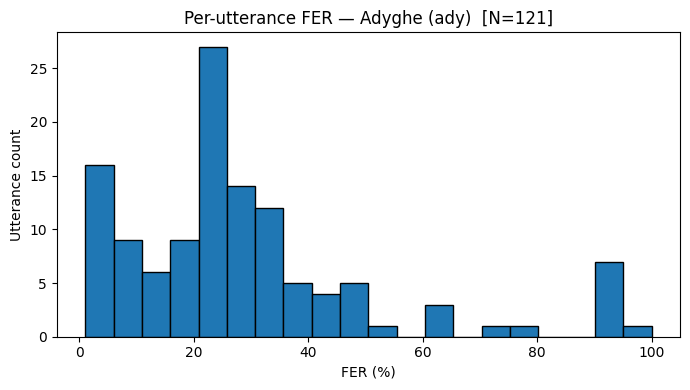

In [43]:
import matplotlib.pyplot as plt

# Change this to any langcode to plot a different language
PLOT_LANG = 'ady'

lang_df = df_utt[df_utt["langcode"] == PLOT_LANG]
lname = lang_df["langname"].iloc[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lang_df["fer"], bins=20, edgecolor="black")
ax.set_xlabel("FER (%)")
ax.set_ylabel("Utterance count")
ax.set_title(f"Per-utterance FER — {lname} ({PLOT_LANG})  [N={len(lang_df)}]")
plt.tight_layout()
plt.show()

In [36]:
# Tag utterances as in-domain / out-of-domain based on training languages
df_utt["domain"] = df_utt["langcode"].apply(
    lambda c: "in-domain" if c in TRAIN_LANGS else "out-of-domain"
)

# Per-language pooled FER (total_fed / total_phones approximated via mean here,
# but we use the utterance-level fer mean as a per-language summary)
lang_fer = (
    df_utt.groupby(["langcode", "langname", "domain"])["fer"]
    .agg(N="count", FER_mean="mean", FER_std="std")
    .reset_index()
    .sort_values("FER_mean", ascending=False)
)

# Summary: macro-average FER per domain
domain_summary = lang_fer.groupby("domain")["FER_mean"].agg(
    n_langs="count",
    macro_FER_mean="mean",
    macro_FER_std="std",
)
print("=== In-domain vs Out-of-domain (macro-avg over languages) ===")
print(domain_summary.to_string())

print(f"\nIn-domain languages in voxangeles:     {sorted(lang_fer[lang_fer['domain']=='in-domain']['langname'].tolist())}")
print(f"\nOut-of-domain languages in voxangeles: {sorted(lang_fer[lang_fer['domain']=='out-of-domain']['langname'].tolist())}")
print('Overall FER', lang_fer["FER_mean"].mean())

=== In-domain vs Out-of-domain (macro-avg over languages) ===
               n_langs  macro_FER_mean  macro_FER_std
domain                                               
in-domain           17       12.456521       4.612036
out-of-domain       78       15.940149       7.894397

In-domain languages in voxangeles:     ['Afrikaans', 'Basque', 'Bengali', 'Croatian', 'Czech', 'Danish', 'Dutch', 'Finnish', 'Hausa', 'Hindi', 'Hungarian', 'Icelandic', 'Lithuanian', 'Malayalam', 'Maltese', 'Modern Greek (1453-)', 'Yue Chinese']

Out-of-domain languages in voxangeles: ['Abkhazian', 'Achinese', 'Adamawa Fulfulde', 'Adyghe', 'Aghul', 'Akan', 'Angami Naga', 'Armenian', 'Assamese', 'Badaga', 'Bafut', 'Bambara', 'Bassa', 'Bemba (Zambia)', 'Bini', 'Bukiyip', 'Bura-Pabir', 'Burmese', 'Cacua', 'Central Atlas Tamazight', 'Chamalal', 'Chamorro', 'Cherepon', 'Columbia-Wenatchi', 'Dagbani', 'Dari', 'Defaka', 'Degema', 'Efik', 'Emai-Iuleha-Ora', 'Ewe', 'Ga', 'Ganda', 'Gua', 'Gujarati', 'Hakka Chinese', 'Hani

In [52]:
from IPython.display import Audio, display
audio_path_pattern = "/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/test_voxangeles/recording/{langcode}/{u}.wav"

def display_audio_for_utterance(utt_id: str):
    langcode = utt_id.split("-")[0]
    audio_path = audio_path_pattern.format(langcode=langcode, u=utt_id)
    display(Audio(audio_path))

for u in df_utt[df_utt.fer>100]["utt_id"][:10]:
    langcode = u.split("-")[0]
    print(f"Utterance {u} (lang: {langcode}, FER: {df_utt[df_utt.utt_id==u]['fer'].iloc[0]:.1f}%)")
    print(f"  Reference: {df_utt[df_utt.utt_id==u]['reference'].iloc[0]}")
    print(f"  Predicted: {df_utt[df_utt.utt_id==u]['predicted'].iloc[0]}")
    display_audio_for_utterance(u)
    

Utterance lit-002-067-28 (lang: lit, FER: 110.2%)
  Reference: iːstʲɾʲɪʒʲaɪ
  Predicted: ɪstrʒɑjəjɪstrɪʒɑs


Utterance mlt-000-036-6 (lang: mlt, FER: 135.0%)
  Reference: ʒdiːdiː
  Predicted: ɕdid̪ias̪tud͡ʑan̪


Utterance nld-004-073-84 (lang: nld, FER: 130.6%)
  Reference: tɔn
  Predicted: t͡ɕɔmn̪okɔ


Utterance pes-001-030-31 (lang: pes, FER: 129.2%)
  Reference: ɢar̥
  Predicted: qorsoad̪


Utterance prs-000-044-19 (lang: prs, FER: 160.4%)
  Reference: ʁɑɾ
  Predicted: ɡb̤ɔruhɔr


Utterance wuu-002-017-48 (lang: wuu, FER: 285.4%)
  Reference: z̩
  Predicted: sɯsɯ


Utterance ben-000-021-15 (lang: ben, FER: 106.9%)
  Reference: gẽo
  Predicted: əndkev


Utterance ilo-000-028-59 (lang: ilo, FER: 115.1%)
  Reference: sili
  Predicted: silisukoɡ̤


In [ ]:
utt_id=df_utt[df_utt.fer>80]

,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per,domain
0,lit-002-067-28,lit,Lithuanian,iːstʲɾʲɪʒʲaɪ,ɪstrʒɑjəjɪstrɪʒɑs,9.625,110.156250,8.812500,175.0,in-domain
135,lkt-000-002-1,lkt,Lakota,pxa,,3.000,91.666667,2.750000,100.0,out-of-domain
139,lkt-000-007-5,lkt,Lakota,kʼu,,2.000,91.666667,1.833333,100.0,out-of-domain
147,lkt-000-031-13,lkt,Lakota,pʃĩ,,3.000,92.361111,2.770833,100.0,out-of-domain
297,mal-001-015-5,mal,Malayalam,teːɲːu,,4.000,92.187500,3.687500,100.0,in-domain
...,...,...,...,...,...,...,...,...,...,...
5400,led-001-002-2,led,Lendu,ɓ̥a,,2.000,91.666667,1.833333,100.0,out-of-domain
5404,led-001-006-6,led,Lendu,ɓ̥i,,2.000,91.666667,1.833333,100.0,out-of-domain
5412,led-001-014-14,led,Lendu,ɓ̥ɔ,,2.000,91.666667,1.833333,100.0,out-of-domain
5415,led-001-017-17,led,Lendu,ɗ̥a,,2.000,92.708333,1.854167,100.0,out-of-domain
